# 00 — Dataset Extraction & Exploration

Build the aligned **Lakh MIDI ↔ MSD (Million Song Dataset)** table, deduplicate it, enrich it with **MIDI instrumentation** (program numbers / instrument names extracted with `pretty_midi`), and persist it as Parquet for downstream notebooks.

**Pipeline**
1. Point to local dataset roots
2. Discover tracks via `LakhMSDLinker`
3. Filter by DTW match score (>= 0.55)
4. Read MSD HDF5 metadata (h5py)
5. Extract MIDI instrumentation with `pretty_midi` (programs → GM names → 16 GM families)
6. Deduplicate by MIDI hash + artist/title
7. Exploratory statistics & plots — MSD scalars **and** MIDI instrumentation
8. Save to `data/processed/lakh_msd_dataset.parquet`


In [6]:
import sys, pathlib, os
if str(pathlib.Path(os.getcwd()).name) == 'DL-KG-project':
    os.chdir('notebooks')
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'src'))

import warnings
warnings.filterwarnings('ignore')

from data.dataset_extraction import LakhMSDLinker, read_msd_metadata, load_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
print("Imports OK")

Imports OK


In [7]:
import sys, subprocess
print("Kernel python:", sys.executable)

# Install pretty_midi into THIS kernel's interpreter (idempotent).
try:
    import pretty_midi  # noqa: F401
    print("pretty_midi already installed:", pretty_midi.__version__)
except ImportError:
    print("Installing pretty_midi into:", sys.executable)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "pretty_midi"])
    import importlib, site
    importlib.reload(site)
    import pretty_midi  # noqa: F401
    print("Installed pretty_midi:", pretty_midi.__version__)


Kernel python: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/SONATAM/.venv/bin/python
Installing pretty_midi into: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/SONATAM/.venv/bin/python
Installed pretty_midi: 0.2.11
Installed pretty_midi: 0.2.11



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 0 — Download Lakh MIDI Dataset (run once)

Downloads three assets into `data/raw/` and writes a `manifest.json` so the rest of the notebook can pick up the paths automatically:

| Asset | Size | Destination |
|-------|------|-------------|
| `lmd_matched.tar.gz` | ~1.5 GB | `data/raw/lmd_matched/` |
| `lmd_matched_h5.tar.gz` | ~2.5 GB | `data/raw/lmd_matched_h5/` |
| `match_scores.json` | ~9 MB | `data/raw/match_scores.json` |

> **Skip this cell** if you already have the files — set `SKIP_DOWNLOAD = True`.

In [8]:
import subprocess

SKIP_DOWNLOAD = False          # ← set True once data/raw/ is populated
RAW_DIR       = pathlib.Path('../data/raw').resolve()

if not SKIP_DOWNLOAD:
    result = subprocess.run(
        [sys.executable,
         str(pathlib.Path('..').resolve() / 'scripts' / 'download_lmd.py'),
         '--dest', str(RAW_DIR),
         '--skip-existing'],
        capture_output=False,   # stream output directly to the notebook
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError("Download script failed — check output above.")
else:
    print("SKIP_DOWNLOAD=True — skipping download.")


  DL-KG-project — Lakh MIDI Dataset downloader
  Destination : data/raw
  Assets      : lmd_matched, lmd_matched_h5, match_scores


── lmd_matched  ──  LMD-matched  (~45 k MIDI files matched to MSD)
    ↩  Already exists — skipping  (1.3 GB)
    ↩  Already unpacked  (116,189 files in data/raw/lmd_matched)

── lmd_matched_h5  ──  MSD HDF5 files for every LMD-matched entry
    ↩  Already exists — skipping  (6.2 GB)
    ↩  Already unpacked  (116,189 files in data/raw/lmd_matched)

── lmd_matched_h5  ──  MSD HDF5 files for every LMD-matched entry
    ↩  Already exists — skipping  (6.2 GB)
    ↩  Already unpacked  (31,034 files in data/raw/lmd_matched_h5)

── match_scores  ──  DTW match scores (track_id → md5 → score)
    ↩  Already exists — skipping  (6.9 MB)

  ✓  Done.  Manifest → data/raw/manifest.json

    ↩  Already unpacked  (31,034 files in data/raw/lmd_matched_h5)

── match_scores  ──  DTW match scores (track_id → md5 → score)
    ↩  Already exists — skipping  (6.9 MB)

  ✓  Done.

In [9]:
# ── Auto-detect paths from the manifest written by download_lmd.py ───────────
import json as _json

_manifest_path = RAW_DIR / 'manifest.json'

if _manifest_path.exists():
    with open(_manifest_path) as _f:
        _manifest = _json.load(_f)

    MIDI_ROOT_AUTO         = pathlib.Path(_manifest['lmd_matched']['unpacked'])
    H5_ROOT_AUTO           = pathlib.Path(_manifest['lmd_matched_h5']['unpacked'])
    MATCH_SCORES_PATH_AUTO = pathlib.Path(_manifest['match_scores']['archive'])

    print("Paths loaded from manifest:")
    print(f"  MIDI root        : {MIDI_ROOT_AUTO}")
    print(f"  HDF5 root        : {H5_ROOT_AUTO}")
    print(f"  Match scores     : {MATCH_SCORES_PATH_AUTO}")
    print(f"  MIDI exists      : {MIDI_ROOT_AUTO.exists()}")
    print(f"  HDF5 exists      : {H5_ROOT_AUTO.exists()}")
    print(f"  Scores exists    : {MATCH_SCORES_PATH_AUTO.exists()}")
else:
    # fallback — set manually below
    MIDI_ROOT_AUTO         = pathlib.Path('/path/to/lmd_matched')
    H5_ROOT_AUTO           = pathlib.Path('/path/to/lmd_matched_h5')
    MATCH_SCORES_PATH_AUTO = pathlib.Path('/path/to/match_scores.json')
    print("[WARN] manifest.json not found — set paths manually in the next cell.")

Paths loaded from manifest:
  MIDI root        : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched
  HDF5 root        : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched_h5
  Match scores     : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/match_scores.json
  MIDI exists      : True
  HDF5 exists      : True
  Scores exists    : True


## 1 — Configuration: dataset roots

In [10]:
# ── Override here only if you want to use paths different from the manifest ──
MIDI_ROOT         = MIDI_ROOT_AUTO           # or: pathlib.Path('/custom/path')
H5_ROOT           = H5_ROOT_AUTO
MATCH_SCORES_PATH = MATCH_SCORES_PATH_AUTO

PROCESSED_DIR = pathlib.Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUT_PARQUET = PROCESSED_DIR / 'lakh_msd_dataset.parquet'

MIN_SCORE  = 0.55   # DTW threshold — keep scores >= this (higher = better fit), from Colin Rafel's publication on audio-to-MIDI matching section 4.5
MAX_TRACKS = None   # int (e.g. 5_000) for a quick test run, None = all

# ── Sanity-check ─────────────────────────────────────────────────────────────
for label, p in [('MIDI root', MIDI_ROOT),
                 ('HDF5 root', H5_ROOT),
                 ('match_scores', MATCH_SCORES_PATH)]:
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f"  {status}  {label}: {p}")


  ✓  MIDI root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched
  ✓  HDF5 root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched_h5
  ✓  match_scores: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/match_scores.json


## 2 — Build dataset (discover → filter → read HDF5 → deduplicate)

In [12]:
linker = LakhMSDLinker(
    midi_root          = MIDI_ROOT,
    h5_root            = H5_ROOT,
    match_scores_path  = MATCH_SCORES_PATH,
    min_score          = MIN_SCORE,
    pick_midi          = 'best',   # one row per (track_id, best-MIDI) pair
)

# Notes on what build_dataset does for us:
#   * exact-duplicate MIDI files are removed via md5 hash
#   * include_midi=True parses each kept MIDI with pretty_midi and ALWAYS
#     attaches the two minimal columns (NaN/[] when parsing fails) so the
#     columns exist even on partial failure:
#         - midi_n_instruments     : int
#         - midi_instrument_names  : list[str]  (GM names + 'Drums' if any)
df = linker.build_dataset(max_tracks=MAX_TRACKS, verbose=True, include_midi=True)
print(f"\nDataset shape: {df.shape}")
df.head(3)


Reading HDF5 metadata: 100%|██████████| 30421/30421 [22:49<00:00, 22.22it/s]



MIDI parsed OK for 18859/19037 files (99.1%)
Built dataset: 19037 rows (19037 unique track_ids, 19037 unique song_ids)

Dataset shape: (19037, 40)


,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,audio_md5,artist_name,title,release,...,artist_terms,artist_terms_freq,artist_terms_weight,primary_genre,top3_genres,similar_artists,artist_mbtags,artist_mbtags_count,midi_n_instruments,midi_instrument_names
0,TRAAAGR128F425B14B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.742663,SONRWUU12AF72A4283,ARGE7G11187FB37E05,7bd9e20e-74b9-446a-a2ed-a223f82a36e7,7573fabe891b25bcd3c5866e4c5df1f0,Cyndi Lauper,Into The Nightlife,Bring Ya To The Brink,...,"[new wave, rock, pop, ballad, soundtrack]","[1.0, 0.9496095498321674, 0.9209438924950107, ...","[1.0, 0.8274088968810257, 0.8362373810229121, ...",new wave,"[new wave, rock, pop]","[ARPMB2A1187FB4D306, ARDGYV01187B9BA3DD, ARNCX...",[classic pop and rock],[1],16.0,"[Shamisen, Electric Guitar (muted), Pan Flute,..."
1,TRAAAZF12903CCCF6B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.665684,SOUCVHW12AB018E830,ARJJ8611187FB5321F,471e21ab-7a14-4190-a9d2-f95197616df4,facaf1c26c48d98e6b20c54b4d02051b,Matthew Wilder,Break My Stride,I Don't Speak The Language,...,"[rock, pop rock, electronic, disco, pop]","[1.0, 0.9991508807119213, 0.9825076366910069, ...","[0.8669636173576897, 1.0, 0.8666714916235556, ...",rock,"[rock, pop rock, electronic]","[ARWSN471187B9A6F7F, ARU7CW61187FB51117, AR74P...",[],[],6.0,"[Pad 3 (polysynth), Electric Bass (finger), El..."
2,TRAABVM128F92CA9DC,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.731250,SOXLBJT12A8C140925,ARYKCQI1187FB3B18F,eeacb319-8d4c-48e0-80a0-944e71c375bf,3e57f1f9670a3aa3bd8901e6eee32149,Tesla,Caught In A Dream,Gold,...,"[hard rock, rock, heavy metal, classic rock, b...","[1.0, 0.9731986233060094, 0.9573587331618035, ...","[1.0, 0.8962468895285768, 0.9755238307281503, ...",hard rock,"[hard rock, rock, heavy metal]","[ARO353H1187B9A43E9, ARV8LAR1187FB3DE2A, AREGV...",[],[],15.0,"[Electric Bass (finger), Lead 1 (square), Shak..."


In [ ]:
pd.set_option('display.max_columns', None)
df.head(5)

,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,audio_md5,artist_name,title,release,artist_location,artist_latitude,artist_longitude,artist_familiarity,artist_hotttnesss,song_hotttnesss,key,key_name,key_confidence,mode,mode_name,mode_confidence,tempo,time_signature,time_signature_confidence,duration,loudness,danceability,energy,year,artist_terms,artist_terms_freq,artist_terms_weight,primary_genre,top3_genres,similar_artists,artist_mbtags,artist_mbtags_count,midi_n_instruments,midi_instrument_names
0,TRAAAGR128F425B14B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.742663,SONRWUU12AF72A4283,ARGE7G11187FB37E05,7bd9e20e-74b9-446a-a2ed-a223f82a36e7,7573fabe891b25bcd3c5866e4c5df1f0,Cyndi Lauper,Into The Nightlife,Bring Ya To The Brink,"Brooklyn, NY",NaN,NaN,0.712886,0.559257,NaN,9,A,0.608,0,minor,0.495,123.989,4,0.800,240.63955,-7.322,0.0,0.0,2008.0,"[new wave, rock, pop, ballad, soundtrack]","[1.0, 0.9496095498321674, 0.9209438924950107, ...","[1.0, 0.8274088968810257, 0.8362373810229121, ...",new wave,"[new wave, rock, pop]","[ARPMB2A1187FB4D306, ARDGYV01187B9BA3DD, ARNCX...",[classic pop and rock],[1],16.0,"[Shamisen, Electric Guitar (muted), Pan Flute,..."
1,TRAAAZF12903CCCF6B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.665684,SOUCVHW12AB018E830,ARJJ8611187FB5321F,471e21ab-7a14-4190-a9d2-f95197616df4,facaf1c26c48d98e6b20c54b4d02051b,Matthew Wilder,Break My Stride,I Don't Speak The Language,"New York, NY [Manhattan]",40.79086,-73.96644,0.546102,0.383787,NaN,10,A#,0.456,1,major,0.442,110.129,4,0.711,184.47628,-11.137,0.0,0.0,1983.0,"[rock, pop rock, electronic, disco, pop]","[1.0, 0.9991508807119213, 0.9825076366910069, ...","[0.8669636173576897, 1.0, 0.8666714916235556, ...",rock,"[rock, pop rock, electronic]","[ARWSN471187B9A6F7F, ARU7CW61187FB51117, AR74P...",[],[],6.0,"[Pad 3 (polysynth), Electric Bass (finger), El..."
2,TRAABVM128F92CA9DC,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.731250,SOXLBJT12A8C140925,ARYKCQI1187FB3B18F,eeacb319-8d4c-48e0-80a0-944e71c375bf,3e57f1f9670a3aa3bd8901e6eee32149,Tesla,Caught In A Dream,Gold,NaN,NaN,NaN,0.707200,0.513463,0.684136,7,G,0.725,1,major,0.756,150.062,4,0.931,290.29832,-5.271,0.0,0.0,2004.0,"[hard rock, rock, heavy metal, classic rock, b...","[1.0, 0.9731986233060094, 0.9573587331618035, ...","[1.0, 0.8962468895285768, 0.9755238307281503, ...",hard rock,"[hard rock, rock, heavy metal]","[ARO353H1187B9A43E9, ARV8LAR1187FB3DE2A, AREGV...",[],[],15.0,"[Electric Bass (finger), Lead 1 (square), Shak..."
3,TRAABXH128F42955D6,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.747489,SOHXFBA12A8C13D637,ARD9UVF1187B9B17FE,634fe78e-fc6b-4b2a-ba83-c8c66e13a8aa,5c745118da3ab07e825a71a74285317a,Brian Wilson,Keep An Eye On Summer (Album Version),Imagination,"Hawthorne, CA",NaN,NaN,0.635346,0.463478,NaN,0,C,0.482,1,major,0.514,100.494,3,1.000,168.64608,-7.108,0.0,0.0,1998.0,"[pop rock, chamber pop, rock, pop, jazz]","[1.0, 0.9620041857591523, 0.9214438433975471, ...","[0.9643539742005119, 1.0, 0.7886675629558219, ...",pop rock,"[pop rock, chamber pop, rock]","[ARXAEXF1187FB36B82, ARJH9DS1187B9B4FF3, AR2DG...",[classic pop and rock],[1],13.0,"[Electric Bass (finger), Overdriven Guitar, Al..."
4,TRAACQE12903CC706C,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.749786,SOGUCAN12AB017BF99,ARDDIBO1187B9B0822,7720a649-0c70-4c7a-972a-c29ccb898201,a296c6b70f0f6600bd0e4d93ad0c7648,Old Man River,Summer,Good Morning,NaN,NaN,NaN,0.583006,0.333922,NaN,7,G,0.233,1,major,0.453,118.430,4,0.610,165.40689,-5.033,0.0,0.0,2007.0,"[alternative rock, hip hop, singer-songwriter,...","[1.0, 0.9999791712652858, 0.9999791712652858, ...","[0.8580177306034834, 0.8713905688080171, 0.852...",alternative rock,"[alternative rock, hip hop, singer-songwriter]","[AR4YF0X1187FB3B924, ARRG7RX1187B99DCE8, ARJBA...",[],[],10.0,"[Electric Guitar (clean), Acoustic Guitar (ste..."


In [14]:
# Quick summary of nulls and dtypes
null_summary = (
    df.isnull()
      .sum()
      .rename('null_count')
      .to_frame()
      .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(2))
      .loc[lambda x: x['null_count'] > 0]
      .sort_values('null_count', ascending=False)
)
display(null_summary)

print("\n=== dtypes ===")
dtypes_summary = df.dtypes.value_counts().rename_axis('dtype').to_frame('count')
display(dtypes_summary)

,null_count,null_pct
artist_latitude,12518,65.76
artist_longitude,12518,65.76
song_hotttnesss,8890,46.70
year,8603,45.19
artist_location,8041,42.24
artist_mbid,1150,6.04
primary_genre,212,1.11
midi_n_instruments,178,0.94
artist_familiarity,2,0.01



=== dtypes ===


,count
dtype,
float64,16
str,13
object,8
int64,3


## 3 — Exploratory statistics

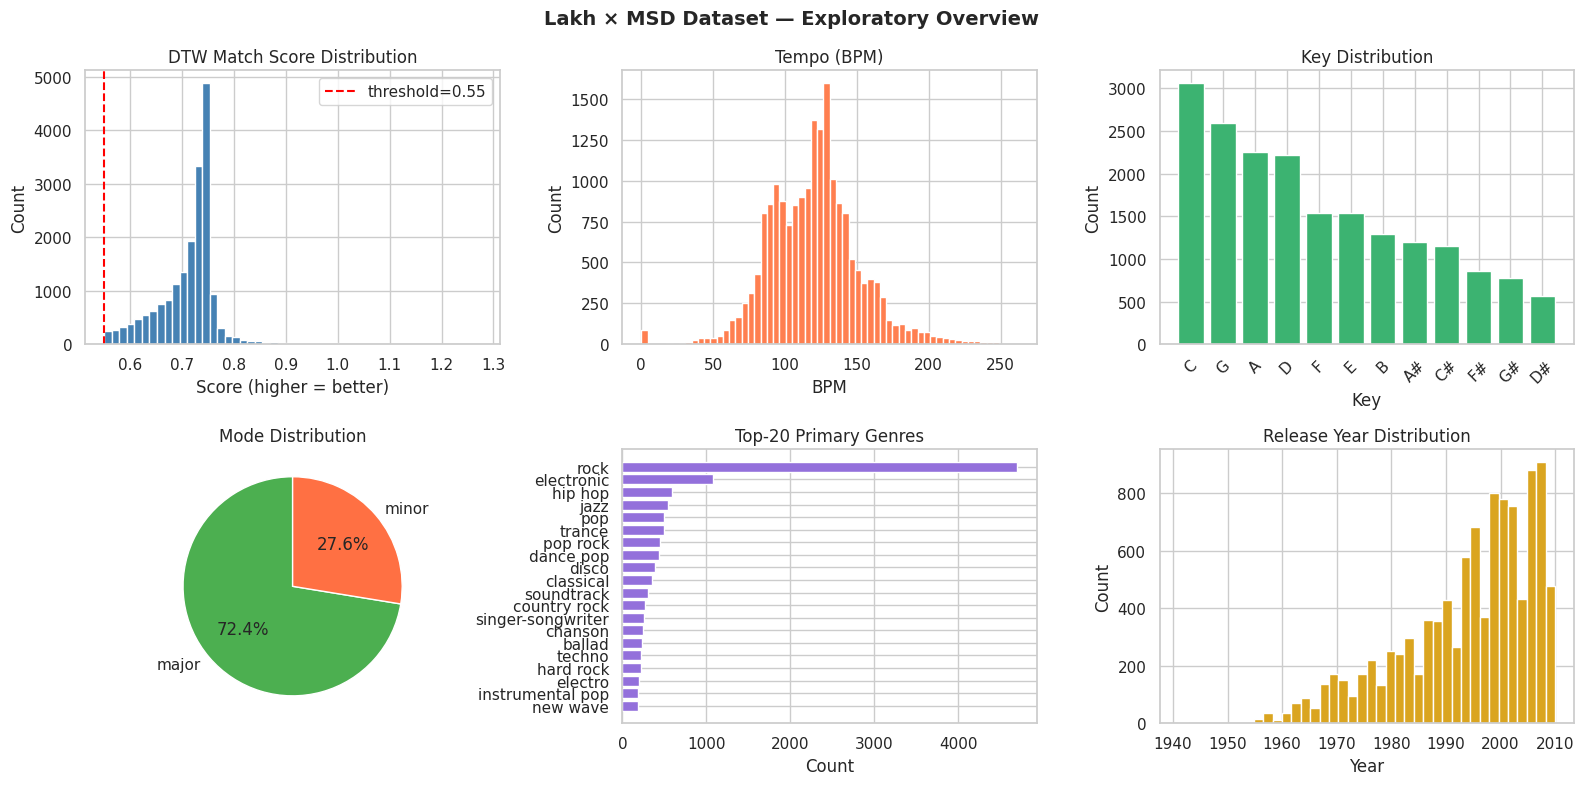

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Lakh × MSD Dataset — Exploratory Overview', fontsize=14, fontweight='bold')

# 1. Match score distribution
ax = axes[0, 0]
ax.hist(df['match_score'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax.set(title='DTW Match Score Distribution', xlabel='Score (higher = better)', ylabel='Count')
ax.axvline(MIN_SCORE, color='red', linestyle='--', label=f'threshold={MIN_SCORE}')
ax.legend()

# 2. Tempo
ax = axes[0, 1]
ax.hist(df['tempo'].dropna(), bins=60, color='coral', edgecolor='white')
ax.set(title='Tempo (BPM)', xlabel='BPM', ylabel='Count')

# 3. Key distribution
ax = axes[0, 2]
key_counts = df['key_name'].value_counts()
ax.bar(key_counts.index, key_counts.values, color='mediumseagreen')
ax.set(title='Key Distribution', xlabel='Key', ylabel='Count')
ax.tick_params(axis='x', rotation=45)

# 4. Mode (major / minor)
ax = axes[1, 0]
mode_counts = df['mode_name'].value_counts()
ax.pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50', '#FF7043'], startangle=90)
ax.set_title('Mode Distribution')

# 5. Top-20 genres
ax = axes[1, 1]
genre_counts = df['primary_genre'].dropna().value_counts().head(20)
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='mediumpurple')
ax.set(title='Top-20 Primary Genres', xlabel='Count')

# 6. Year distribution
ax = axes[1, 2]
years = df['year'].dropna()
years = years[(years > 1900) & (years <= 2023)]
ax.hist(years, bins=40, color='goldenrod', edgecolor='white')
ax.set(title='Release Year Distribution', xlabel='Year', ylabel='Count')

plt.tight_layout()
plt.show()


In [16]:
print("=== Numeric summary ===")
num_cols = ['match_score', 'tempo', 'duration', 'loudness',
            'danceability', 'energy', 'key_confidence', 'mode_confidence']
df[num_cols].describe().round(3)


=== Numeric summary ===


,match_score,tempo,duration,loudness,danceability,energy,key_confidence,mode_confidence
count,19037.000,19037.000,19037.000,19037.000,19037.0,19037.0,19037.000,19037.000
mean,0.713,120.158,248.111,-10.574,0.0,0.0,0.500,0.529
std,0.059,31.699,100.290,5.442,0.0,0.0,0.279,0.194
min,0.550,0.000,0.626,-43.136,0.0,0.0,0.000,0.000
25%,0.685,98.301,191.791,-12.906,0.0,0.0,0.295,0.414
50%,0.728,120.484,233.038,-9.300,0.0,0.0,0.528,0.542
75%,0.745,136.974,283.742,-6.794,0.0,0.0,0.708,0.662
max,1.276,262.183,2149.329,-0.205,0.0,0.0,1.000,1.000


### 3.0.1 — A note on missing `year`

We can observe that 45–50 % of `year` values are missing, that is **expected**: the MSD
stores `year = 0` whenever no release year is known, and that affects roughly
half of the corpus. We mapped `0 →
NaN`, so missing values surface honestly as nulls instead of pretending the
song was released in year 0.

### 3.0.2  `track_id` versus`song_id` distribution

In [23]:
# Versions per song: how many distinct track_ids share each song_id?
if 'song_id' in df.columns:
    versions = (
        df.dropna(subset=['song_id'])
          .groupby('song_id')['track_id']
          .nunique()
    )

    n_total_tracks    = len(df)
    n_unique_songs    = versions.size
    n_multi_version   = int((versions > 1).sum())
    pct_multi_version = 100 * n_multi_version / max(n_unique_songs, 1)

    print(f"Total rows (track_id-MIDI pairs) : {n_total_tracks:,}")
    print(f"Unique song_ids                  : {n_unique_songs:,}")
    print(f"song_ids with >1 track_id        : {n_multi_version:,} "
          f"({pct_multi_version:.1f}%)")
    print(f"Max track_ids for a single song  : {int(versions.max())}")

Total rows (track_id-MIDI pairs) : 19,037
Unique song_ids                  : 19,037
song_ids with >1 track_id        : 0 (0.0%)
Max track_ids for a single song  : 1


## 3.1 — MIDI instrumentation exploration

With `include_midi=True`, `build_dataset` parses every kept MIDI with
`pretty_midi` and attaches just two columns — everything else is derivable on
demand and would only inflate the DataFrame:

| Column | Type | Meaning |
|---|---|---|
| `midi_n_instruments` | int | total number of instrument tracks (incl. drum kits) |
| `midi_instrument_names` | list[str] | unique General-MIDI instrument names (`pretty_midi.program_to_instrument_name(program)`), with `'Drums'` appended once if any drum track is present |

**How instruments are identified.** Each `pretty_midi` instrument track exposes
a GM `program` byte (0-127) set by a Program-Change event. For melodic tracks
we resolve the official GM name with `program_to_instrument_name`. For tracks
with `is_drum=True` (MIDI channel 10) the program byte does **not** map to a
GM melodic instrument — the *note number* selects a percussion sound via the
GM Percussion Map — so we collapse all such tracks into a single `'Drums'`
label. Names are deduplicated so a file with three piano tracks contributes
`'Acoustic Grand Piano'` only once.

The plots below show:
**(1)** distribution of the number of instrument tracks per file,
**(2)** the top-20 most common GM instrument names across the dataset,
**(3)** the share of files containing drums.


MIDI parsed successfully for 18,859 / 19,037 tracks (99.1%)


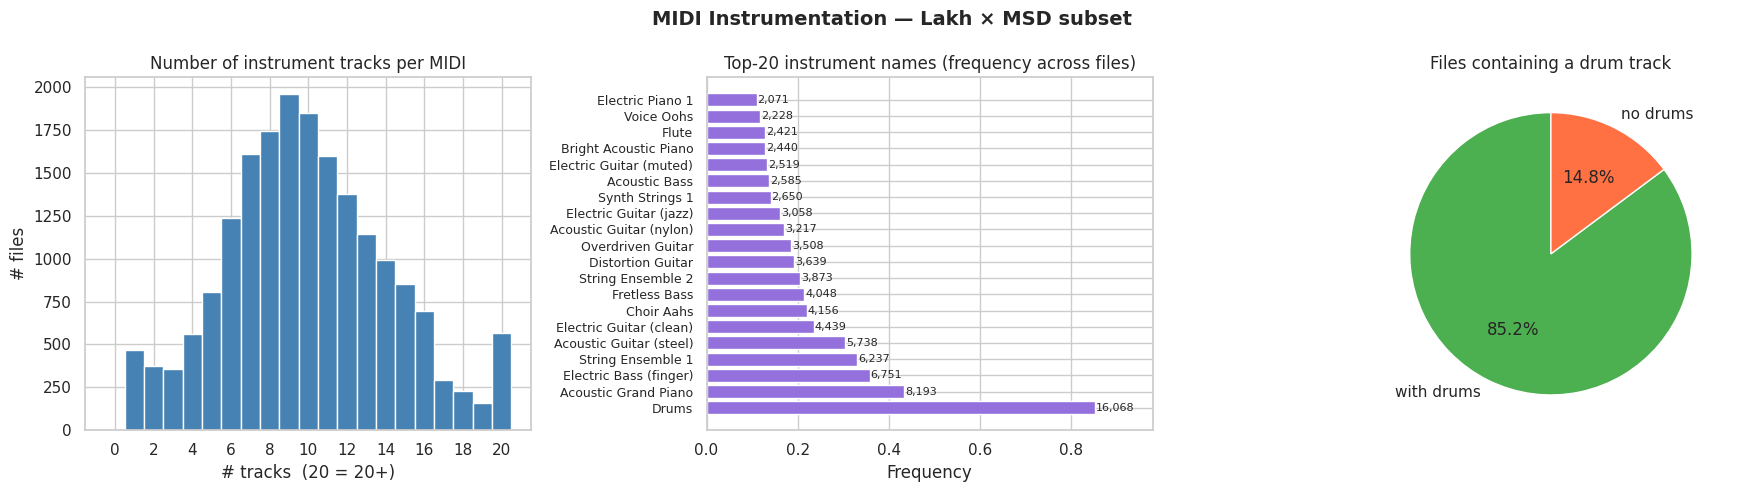

In [25]:
import collections

# guard: skip the whole section if include_midi=False was used upstream
if 'midi_n_instruments' not in df.columns:
       print("[INFO] No MIDI instrumentation columns — rerun build_dataset(..., include_midi=True).")
else:
       midi_df = df.dropna(subset=['midi_n_instruments']).copy()
       print(f"MIDI parsed successfully for {len(midi_df):,} / {len(df):,} tracks "
                f"({100*len(midi_df)/len(df):.1f}%)")

       # flatten the (already-deduped per-file) instrument names
       all_names = [n for lst in midi_df['midi_instrument_names'] for n in (lst or [])]

       fig, axes = plt.subplots(1, 3, figsize=(18, 5))
       fig.suptitle('MIDI Instrumentation — Lakh × MSD subset',
                             fontsize=14, fontweight='bold')

       # 1. Number of instrument tracks per file --------------------------------
       ax = axes[0]
       n_inst = midi_df['midi_n_instruments'].clip(upper=20)
       ax.hist(n_inst, bins=range(0, 22), color='steelblue',
                     edgecolor='white', align='left')
       ax.set(title='Number of instrument tracks per MIDI',
                 xlabel='# tracks  (20 = 20+)', ylabel='# files')
       ax.set_xticks(range(0, 21, 2))

       # 2. Top-20 GM instrument names (frequency) ------------------------------
       ax = axes[1]
       top_names = collections.Counter(all_names).most_common(20)
       labels, counts = zip(*top_names)
       total = len(midi_df)
       freqs = [c / total for c in counts]

       y_pos = list(range(len(labels)))[::-1]
       ax.barh(y_pos, freqs[::-1], color='mediumpurple')
       ax.set_yticks(y_pos)
       ax.set_yticklabels(labels[::-1], fontsize=9)
       ax.set(title='Top-20 instrument names (frequency across files)',
                 xlabel='Frequency')

       # add counts as labels on the right
       for i, (f, c) in enumerate(zip(freqs[::-1], counts[::-1])):
              ax.text(f + 0.002, y_pos[i], f"{c:,}", va='center', fontsize=8)

       ax.set_xlim(0, max(freqs) * 1.15)

       # 3. Drums vs no-drums ---------------------------------------------------
       ax = axes[2]
       has_drums = midi_df['midi_instrument_names'].apply(
              lambda lst: 'Drums' in (lst or [])
       )
       counts = has_drums.value_counts().reindex([True, False], fill_value=0)
       ax.pie(counts.values, labels=['with drums', 'no drums'],
                 autopct='%1.1f%%', colors=['#4CAF50', '#FF7043'], startangle=90)
       ax.set_title('Files containing a drum track')

       plt.tight_layout()
       plt.show()


In [19]:
if 'midi_n_instruments' in df.columns:
    midi_df = df.dropna(subset=['midi_n_instruments'])
    all_names = [n for lst in midi_df['midi_instrument_names'] for n in (lst or [])]
    has_drums = midi_df['midi_instrument_names'].apply(
        lambda lst: 'Drums' in (lst or [])
    )

    summary = pd.DataFrame({
        'metric': [
            '# tracks parsed',
            'mean # instrument tracks / file',
            'median # instrument tracks / file',
            '% files containing drums',
            '# unique instrument names seen',
        ],
        'value': [
            f"{len(midi_df):,}",
            f"{midi_df['midi_n_instruments'].mean():.2f}",
            f"{midi_df['midi_n_instruments'].median():.0f}",
            f"{100 * has_drums.mean():.1f}%",
            f"{len(set(all_names))}",
        ],
    })
    display(summary)


,metric,value
0,# tracks parsed,"18,859"
1,mean # instrument tracks / file,10.08
2,median # instrument tracks / file,10
3,% files containing drums,85.2%
4,# unique instrument names seen,129


## 4 — Save processed dataset

In [20]:
df.to_parquet(OUT_PARQUET, index=False)
print(f"Saved {len(df):,} rows → {OUT_PARQUET}")

# also save a lighter CSV (without list columns) for quick inspection
csv_cols = [c for c in df.columns if not isinstance(df[c].iloc[0], list)]
df[csv_cols].to_csv(OUT_PARQUET.with_suffix('.csv'), index=False)
print("CSV saved (no list columns).")

Saved 19,037 rows → ../data/processed/lakh_msd_dataset.parquet
CSV saved (no list columns).
CSV saved (no list columns).
